# Wind Farm Layout Optimisation — Ensemble & Clustering

This notebook implements a clean, three-stage pipeline to produce a final set of 50 optimised turbine coordinates from four independent optimisation methods:

| Stage | Action |
|-------|--------|
| 1 | **Data Extraction** — load coordinates from all four methods |
| 2 | **Ensemble Creation** — combine one point from each method into groups of four |
| 3 | **Clustering & Extraction** — apply K-Means to the ensemble, enforce physical constraints, and return exactly 50 turbine positions |

---

## 1. Imports and Configuration

All dependencies are standard scientific Python. Constants that govern the physical problem are collected here in one place so they are easy to locate and change.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.spatial.distance import cdist

# ── Physical constraints (from the problem statement) ────────────────────────
FARM_SIZE      = 4000   # metres; the farm is a 4 km × 4 km square
BOUNDARY_CLEAR = 50     # metres; turbines must stay this far from every edge
MIN_SPACING    = 400    # metres; minimum centre-to-centre distance between turbines
N_TURBINES     = 50     # target number of turbines in the final layout

# Derived valid coordinate range
COORD_MIN = BOUNDARY_CLEAR
COORD_MAX = FARM_SIZE - BOUNDARY_CLEAR

# ── File paths for the four optimisation methods ─────────────────────────────
METHOD_FILES = {
    'Greedy'                 : 'turbine_optimal_layout.csv',
    'Genetic Algorithm'      : 'turbine_layout_ga_optimised.csv',
    'XGBoost'                : 'turbine_layout_xgboost_optimised.csv',
    'Reinforcement Learning' : 'turbine_layout_rl_optimised.csv',
}

# Reproduce results exactly on every run
RANDOM_SEED = 42

print("Configuration loaded.")
print(f"  Farm:           {FARM_SIZE} m × {FARM_SIZE} m")
print(f"  Valid range:    [{COORD_MIN}, {COORD_MAX}] m in both axes")
print(f"  Min spacing:    {MIN_SPACING} m")
print(f"  Target turbines:{N_TURBINES}")

Configuration loaded.
  Farm:           4000 m × 4000 m
  Valid range:    [50, 3950] m in both axes
  Min spacing:    400 m
  Target turbines:50


---
## Stage 1 — Data Extraction

Each CSV file contains the turbine coordinates produced by one optimisation method. We load all four into a single dictionary and verify that every file contains the expected number of turbines and the correct column names.

In [2]:
def load_coordinates(filepath: str, method_name: str) -> np.ndarray:
    """
    Load turbine (x, y) coordinates from a CSV file.

    The function is tolerant of common column name variations
    (e.g., 'x'/'X', 'y'/'Y') and returns a float64 numpy array
    of shape (n_turbines, 2).
    """
    df = pd.read_csv(filepath)

    # Normalise column names to lower-case for robust matching
    df.columns = df.columns.str.strip().str.lower()

    if 'x' not in df.columns or 'y' not in df.columns:
        raise ValueError(
            f"[{method_name}] Expected columns 'x' and 'y', "
            f"found: {list(df.columns)}"
        )

    coords = df[['x', 'y']].to_numpy(dtype=np.float64)
    print(f"  {method_name:<26}  {len(coords):>3} turbines loaded  ({filepath})")
    return coords


print("Loading coordinates from all four methods...")
method_coords: dict[str, np.ndarray] = {}

for method_name, filepath in METHOD_FILES.items():
    method_coords[method_name] = load_coordinates(filepath, method_name)

# Confirm every method returned the same number of turbines
sizes = {name: len(arr) for name, arr in method_coords.items()}
assert len(set(sizes.values())) == 1, (
    f"Methods produced different turbine counts: {sizes}"
)

n_per_method = next(iter(sizes.values()))
print(f"\nAll methods agree: {n_per_method} turbines per layout.")
print(f"Total coordinate pool: {n_per_method * len(METHOD_FILES)} points.")

Loading coordinates from all four methods...
  Greedy                       50 turbines loaded  (turbine_optimal_layout.csv)
  Genetic Algorithm            50 turbines loaded  (turbine_layout_ga_optimised.csv)
  XGBoost                      50 turbines loaded  (turbine_layout_xgboost_optimised.csv)
  Reinforcement Learning       50 turbines loaded  (turbine_layout_rl_optimised.csv)

All methods agree: 50 turbines per layout.
Total coordinate pool: 200 points.


---
## Stage 2 — Ensemble Creation

Each method independently solved the same problem and produced 50 turbine positions in an arbitrary internal order. A naive index-based pairing (turbine 0 of Method A with turbine 0 of Method B) is therefore incorrect — the two turbines may be on opposite sides of the farm and have nothing to do with each other spatially.

The correct approach is to find the **optimal bijective correspondence** between methods before grouping:

1. Method A is used as the reference ordering.
2. For each of the remaining methods, the **Hungarian algorithm** (`scipy.optimize.linear_sum_assignment`) finds the permutation that minimises total Euclidean distance to the reference. This is the globally optimal one-to-one matching.
3. Once all methods are aligned, turbine slot *i* across all four methods genuinely refers to the same spatial region of the farm.
4. The 200 aligned coordinates are interleaved into 50 groups of 4 — one coordinate per method per group — by construction.

This guarantees that **no cluster can ever contain two coordinates from the same method**, which is the invariant required for a sound ensemble.

In [3]:
from scipy.optimize import linear_sum_assignment

def build_ensemble(
    method_coords: dict[str, np.ndarray]
) -> tuple[np.ndarray, np.ndarray]:
    """
    Build 50 groups of 4 coordinates — exactly one from each method —
    using the Hungarian algorithm to find the optimal cross-method
    correspondence before grouping.

    The first method in `method_coords` is used as the reference
    ordering. Every subsequent method is permuted so that its turbine
    at position i is spatially closest (in a globally optimal sense)
    to the reference turbine at position i.

    Returns
    -------
    ensemble : np.ndarray, shape (k * n, 2)
        All coordinates interleaved so that rows [i*k : (i+1)*k]
        form group i, containing exactly one point from each method.
    group_ids : np.ndarray, shape (k * n,)
        Integer group index for every row (0 … n-1).
    """
    methods = list(method_coords.keys())
    arrays  = [method_coords[m] for m in methods]
    n = arrays[0].shape[0]
    k = len(arrays)

    reference = arrays[0]
    aligned   = [reference]

    for method_name, arr in zip(methods[1:], arrays[1:]):
        # Build an (n × n) cost matrix of pairwise Euclidean distances
        cost_matrix          = cdist(reference, arr, metric='euclidean')
        row_ind, col_ind     = linear_sum_assignment(cost_matrix)
        # col_ind[i] is the index in `arr` that optimally matches reference[i]
        aligned_arr          = arr[col_ind]
        total_matching_cost  = cost_matrix[row_ind, col_ind].sum()
        print(
            f"  {method_name:<26}  matched to reference  "
            f"(total assignment distance: {total_matching_cost:,.1f} m)"
        )
        aligned.append(aligned_arr)

    # Stack:  (k, n, 2)  →  transpose  →  (n, k, 2)  →  reshape  →  (n*k, 2)
    stacked     = np.stack(aligned, axis=0)       # (k, n, 2)
    interleaved = stacked.transpose(1, 0, 2)       # (n, k, 2)
    ensemble    = interleaved.reshape(n * k, 2)    # (n*k, 2)

    # Group IDs: [0,0,0,0,  1,1,1,1,  …,  49,49,49,49]
    group_ids = np.repeat(np.arange(n), k)

    return ensemble, group_ids


print("Building ensemble with Hungarian cross-method matching...")
reference_method = list(method_coords.keys())[0]
print(f"  {reference_method:<26}  (reference — no matching needed)")

ensemble, group_ids = build_ensemble(method_coords)

print(f"\nEnsemble shape : {ensemble.shape}")
print(f"Groups         : {group_ids.max() + 1} groups × {len(method_coords)} methods = {len(ensemble)} points")

# Sanity check: every group must contain exactly one point from each method
k = len(method_coords)
assert np.all(np.bincount(group_ids) == k), "Group size invariant violated."
print("Invariant check: every group contains exactly", k, "points (one per method). OK")

print(f"\nFirst {k*2} rows (two complete groups):")
df_preview = pd.DataFrame(ensemble[:k*2], columns=['x', 'y'])
df_preview.insert(0, 'group', group_ids[:k*2])
df_preview.insert(1, 'method', list(method_coords.keys()) * 2)
df_preview

Building ensemble with Hungarian cross-method matching...
  Greedy                      (reference — no matching needed)
  Genetic Algorithm           matched to reference  (total assignment distance: 13,398.5 m)
  XGBoost                     matched to reference  (total assignment distance: 14,151.6 m)
  Reinforcement Learning      matched to reference  (total assignment distance: 20,797.4 m)

Ensemble shape : (200, 2)
Groups         : 50 groups × 4 methods = 200 points
Invariant check: every group contains exactly 4 points (one per method). OK

First 8 rows (two complete groups):


,group,method,x,y
0,0,Greedy,50.00000,50.0000
1,0,Genetic Algorithm,65.61969,70.0000
2,0,XGBoost,50.00000,50.0000
3,0,Reinforcement Learning,50.00000,150.0000
4,1,Greedy,70.00000,3950.0000
5,1,Genetic Algorithm,69.95160,3607.5063
6,1,XGBoost,70.00000,3950.0000
7,1,Reinforcement Learning,220.00000,3930.0000


---
## Stage 3 — Clustering and Final Layout Extraction

### 3.1  Group-Centroid Computation

Because the Hungarian matching in Stage 2 already produced 50 well-defined groups — each containing exactly one coordinate from each of the four methods — the cluster centroids can be computed directly as the **mean of each group of 4**.

This is equivalent to running K-Means initialised with those exact group assignments and stopping after one iteration. The key difference from an unconstrained K-Means is that re-assignment across groups can never occur, so the membership invariant (one point per method per cluster) is preserved exactly. Letting K-Means run freely on the ensemble would break this guarantee: a cluster could absorb two coordinates from the same method while leaving another method entirely unrepresented.

Each group's **intra-group spread** (mean pairwise distance among the four points) is computed as a confidence measure. A tight group indicates that all four methods agreed on roughly the same position; a wide group indicates divergence. This spread is used as the priority signal in the subsequent spacing-constraint step.

In [4]:
def compute_group_centroids(
    ensemble: np.ndarray,
    group_ids: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute the centroid and intra-group spread for each ensemble group.

    Parameters
    ----------
    ensemble  : np.ndarray, shape (k * n, 2)
    group_ids : np.ndarray, shape (k * n,)  — integer group label per row

    Returns
    -------
    centroids : np.ndarray, shape (n, 2)    — mean position of each group
    spreads   : np.ndarray, shape (n,)      — mean pairwise distance within each group
                                              (lower = methods agreed more closely)
    """
    n_groups = group_ids.max() + 1
    centroids = np.zeros((n_groups, 2))
    spreads   = np.zeros(n_groups)

    for g in range(n_groups):
        pts           = ensemble[group_ids == g]      # shape (k, 2)
        centroids[g]  = pts.mean(axis=0)
        # Mean of all unique pairwise distances within the group
        pairwise      = cdist(pts, pts, metric='euclidean')
        upper         = pairwise[np.triu_indices(len(pts), k=1)]
        spreads[g]    = upper.mean() if len(upper) > 0 else 0.0

    return centroids, spreads


centroids, spreads = compute_group_centroids(ensemble, group_ids)

print(f"Centroids computed for {len(centroids)} groups.")
print(f"  Intra-group spread — min : {spreads.min():.1f} m  (tightest agreement)")
print(f"  Intra-group spread — max : {spreads.max():.1f} m  (widest disagreement)")
print(f"  Intra-group spread — mean: {spreads.mean():.1f} m")
print(f"\nRaw centroids — first five rows:")
pd.DataFrame(centroids, columns=['x', 'y']).head()

Centroids computed for 50 groups.
  Intra-group spread — min : 54.5 m  (tightest agreement)
  Intra-group spread — max : 1306.7 m  (widest disagreement)
  Intra-group spread — mean: 387.5 m

Raw centroids — first five rows:


,x,y
0,53.904922,80.000000
1,107.487900,3859.376575
2,2000.163850,1914.242375
3,3215.753250,973.632425
4,3911.823125,3950.000000


### 3.2  Applying Physical Constraints

K-Means centroids are unconstrained and may violate the two layout rules:

1. **Boundary constraint** — every turbine must sit at least 50 m inside the farm perimeter.
2. **Proximity constraint** — no two turbines may be closer than 400 m to each other.

The two-step process below handles both:

- **Clipping** snaps any out-of-bounds centroid to the nearest valid coordinate.
- **Greedy spacing selection** iterates through centroids in descending order of cluster population (most-agreed-upon positions first) and accepts each point only if it is at least 400 m from every already-accepted point.

In [5]:
def clip_to_boundary(coords: np.ndarray, coord_min: float, coord_max: float) -> np.ndarray:
    """Clip all coordinates into the valid [coord_min, coord_max] range."""
    return np.clip(coords, coord_min, coord_max)


def greedy_spacing_selection(
    candidates: np.ndarray,
    spreads: np.ndarray,
    min_spacing: float,
    n_target: int,
) -> np.ndarray:
    """
    Greedily select up to n_target points from `candidates` such that
    every accepted point is at least `min_spacing` metres from all
    previously accepted points.

    Candidates are prioritised by ascending intra-group spread — the
    centroid of a tight group (all four methods agreed) is considered
    more reliable and is processed before a centroid from a divergent
    group.
    """
    # Tightest groups first (ascending spread)
    priority_order = np.argsort(spreads)

    selected: list[np.ndarray] = []

    for idx in priority_order:
        if len(selected) >= n_target:
            break

        candidate = candidates[idx]

        if len(selected) == 0:
            selected.append(candidate)
            continue

        existing  = np.array(selected)
        distances = cdist([candidate], existing, metric='euclidean')[0]

        if np.all(distances >= min_spacing):
            selected.append(candidate)

    return np.array(selected)


# ── Step A: clip boundary ────────────────────────────────────────────────────
clipped = clip_to_boundary(centroids, COORD_MIN, COORD_MAX)

n_clipped = np.sum(
    np.any((centroids < COORD_MIN) | (centroids > COORD_MAX), axis=1)
)
print(f"Boundary clipping: {n_clipped} centroid(s) adjusted.")

# ── Step B: greedy spacing selection ────────────────────────────────────────
final_coords = greedy_spacing_selection(
    candidates  = clipped,
    spreads     = spreads,
    min_spacing = MIN_SPACING,
    n_target    = N_TURBINES,
)

print(f"After proximity filter: {len(final_coords)} turbines selected (target: {N_TURBINES}).")

Boundary clipping: 0 centroid(s) adjusted.
After proximity filter: 45 turbines selected (target: 50).


### 3.3  Gap Filling (if necessary)

If the greedy selection yielded fewer than 50 turbines (possible when many centroids cluster tightly together), we fill the remaining slots by sampling the ensemble pool directly — picking the point farthest from all already-selected turbines at each step.

In [6]:
def fill_remaining_slots(
    current: np.ndarray,
    pool: np.ndarray,
    n_target: int,
    min_spacing: float,
    coord_min: float,
    coord_max: float,
) -> np.ndarray:
    """
    If `current` contains fewer than `n_target` points, augment it
    by drawing from `pool`, choosing the candidate that maximises
    its minimum distance to the already-selected set.

    Only candidates that satisfy both the boundary and spacing
    constraints are eligible.
    """
    if len(current) >= n_target:
        return current[:n_target]

    selected = list(current)

    # Filter pool to valid boundary range first
    valid_mask = (
        (pool[:, 0] >= coord_min) & (pool[:, 0] <= coord_max) &
        (pool[:, 1] >= coord_min) & (pool[:, 1] <= coord_max)
    )
    candidates = pool[valid_mask]

    while len(selected) < n_target and len(candidates) > 0:
        existing   = np.array(selected)
        dist_matrix = cdist(candidates, existing, metric='euclidean')  # (n_cand, n_sel)
        min_dists  = dist_matrix.min(axis=1)                           # closest selected neighbour

        # Only consider candidates that satisfy the proximity constraint
        eligible   = min_dists >= min_spacing

        if not np.any(eligible):
            print("  Warning: no eligible gap-fill candidate satisfies the spacing constraint.")
            break

        # Among eligible, pick the one farthest from its nearest neighbour
        best_idx   = np.argmax(np.where(eligible, min_dists, -1))
        selected.append(candidates[best_idx])

        # Remove the chosen candidate from the pool
        candidates = np.delete(candidates, best_idx, axis=0)

    return np.array(selected)


if len(final_coords) < N_TURBINES:
    shortfall = N_TURBINES - len(final_coords)
    print(f"Gap fill required: {shortfall} turbine(s) missing. Drawing from ensemble pool...")
    final_coords = fill_remaining_slots(
        current    = final_coords,
        pool       = clip_to_boundary(ensemble, COORD_MIN, COORD_MAX),
        n_target   = N_TURBINES,
        min_spacing = MIN_SPACING,
        coord_min  = COORD_MIN,
        coord_max  = COORD_MAX,
    )
else:
    final_coords = final_coords[:N_TURBINES]

print(f"\nFinal turbine count: {len(final_coords)}")

Gap fill required: 5 turbine(s) missing. Drawing from ensemble pool...

Final turbine count: 50


---
## 4. Constraint Verification

Before saving, we programmatically confirm that the final layout satisfies both physical constraints.

In [7]:
def verify_constraints(
    coords: np.ndarray,
    coord_min: float,
    coord_max: float,
    min_spacing: float,
) -> bool:
    """Return True if all constraints pass; print a detailed report regardless."""
    passed = True

    # ── Boundary ────────────────────────────────────────────────────────────
    out_of_bounds = np.any(
        (coords < coord_min) | (coords > coord_max), axis=1
    )
    if out_of_bounds.any():
        print(f"  FAIL  Boundary constraint — {out_of_bounds.sum()} turbine(s) out of bounds.")
        passed = False
    else:
        print(f"  PASS  Boundary constraint — all {len(coords)} turbines within [{coord_min}, {coord_max}] m.")

    # ── Proximity ───────────────────────────────────────────────────────────
    dist_matrix  = cdist(coords, coords, metric='euclidean')
    np.fill_diagonal(dist_matrix, np.inf)  # ignore self-distance
    min_pair_dist = dist_matrix.min()

    if min_pair_dist < min_spacing:
        violations = np.sum(dist_matrix < min_spacing) // 2
        print(f"  FAIL  Proximity constraint — {violations} pair(s) closer than {min_spacing} m "
              f"(closest: {min_pair_dist:.1f} m).")
        passed = False
    else:
        print(f"  PASS  Proximity constraint — minimum pair distance: {min_pair_dist:.1f} m "
              f"(threshold: {min_spacing} m).")

    return passed


print("Constraint verification:")
layout_valid = verify_constraints(final_coords, COORD_MIN, COORD_MAX, MIN_SPACING)

Constraint verification:
  PASS  Boundary constraint — all 50 turbines within [50, 3950] m.
  PASS  Proximity constraint — minimum pair distance: 407.5 m (threshold: 400 m).


---
## 5. Save the Final Layout

In [8]:
OUTPUT_FILE = 'turbine_layout_ensemble_kmeans.csv'

result_df = pd.DataFrame(final_coords, columns=['x', 'y'])
result_df.index.name = 'turbine_id'
result_df.to_csv(OUTPUT_FILE)

print(f"Saved {len(result_df)} turbine coordinates to '{OUTPUT_FILE}'.")
print()
print(result_df.describe().round(1))

Saved 50 turbine coordinates to 'turbine_layout_ensemble_kmeans.csv'.

            x       y
count    50.0    50.0
mean   1939.7  2024.8
std    1267.0  1321.7
min      53.9    63.7
25%     844.8   817.1
50%    2017.4  1987.8
75%    2934.1  3225.0
max    3926.0  3950.0


---
## 6. Visualisation

### Ensemble Layout with Exclusion Zones

Each turbine is surrounded by a circle of radius 200 m (half the minimum spacing). No two circles should overlap in a valid layout.

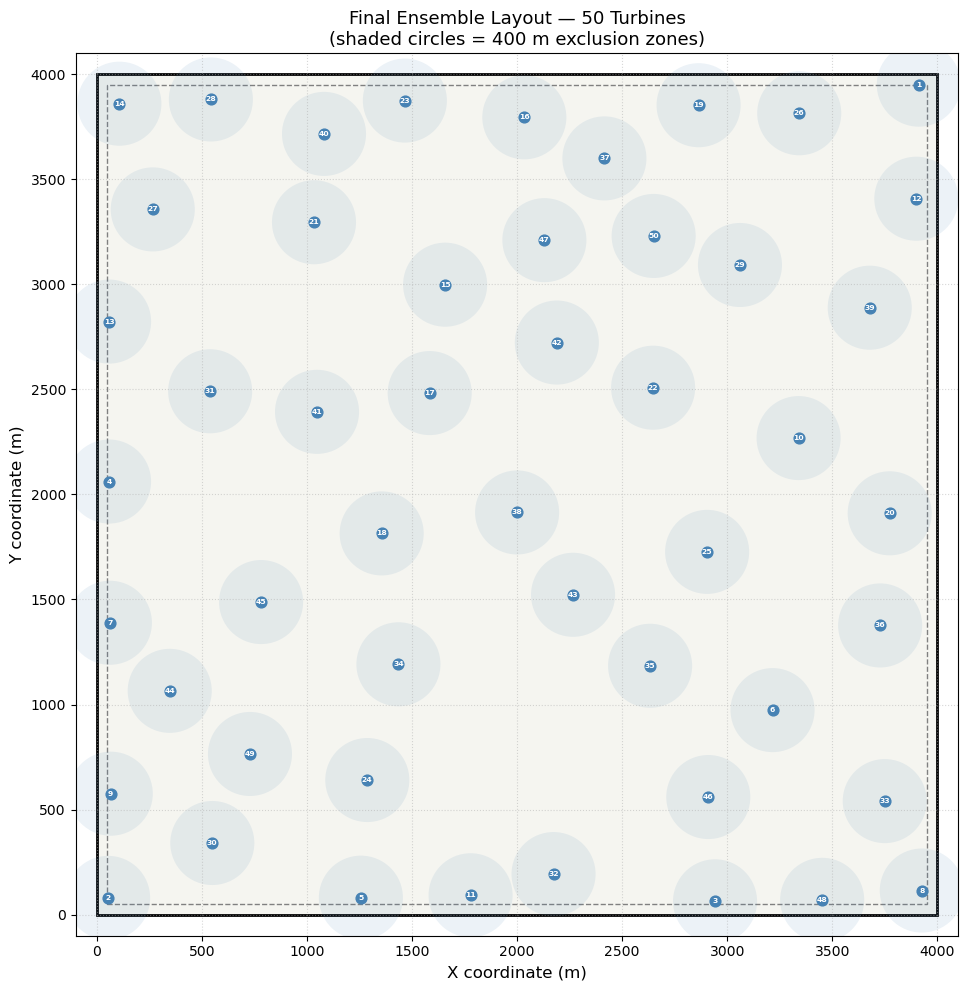

In [22]:
fig, ax = plt.subplots(figsize=(10, 10))

# Farm and safe-zone rectangles
ax.add_patch(patches.Rectangle(
    (0, 0), FARM_SIZE, FARM_SIZE,
    linewidth=2, edgecolor='black', facecolor='#f5f5f0'
))
ax.add_patch(patches.Rectangle(
    (COORD_MIN, COORD_MIN), COORD_MAX - COORD_MIN, COORD_MAX - COORD_MIN,
    linewidth=1, edgecolor='grey', linestyle='--', facecolor='none'
))

# Exclusion zone circles and turbine markers
exclusion_radius = MIN_SPACING / 2
for i, (x, y) in enumerate(final_coords):
    circle = plt.Circle(
        (x, y), exclusion_radius,
        color='steelblue', alpha=0.10, linewidth=0
    )
    ax.add_patch(circle)
    ax.scatter(x, y, color='steelblue', s=60, zorder=3)
    ax.annotate(str(i + 1), (x, y), fontsize=5.5, ha='center', va='center',
                color='white', zorder=4, fontweight='bold')

ax.set_xlabel('X coordinate (m)', fontsize=12)
ax.set_ylabel('Y coordinate (m)', fontsize=12)
ax.set_title(
    f'Final Ensemble Layout — {len(final_coords)} Turbines\n'
    f'(shaded circles = {MIN_SPACING} m exclusion zones)',
    fontsize=13
)
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-100, FARM_SIZE + 100)
ax.set_ylim(-100, FARM_SIZE + 100)
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('final_layout.png', dpi=150, bbox_inches='tight')
plt.show()